In [1]:
import os
import numpy as np
from PIL import Image

root = r"C:\Users\Syed\segmentation\archive\train"

samples = os.listdir(root)

print("Total samples:", len(samples))

# inspect first 3 samples (you can increase later)
for sample in samples[:3]:

    print("\n=========================")
    print("Sample ID:", sample)

    sample_path = os.path.join(root, sample)

    img_dir = os.path.join(sample_path, "images")
    mask_dir = os.path.join(sample_path, "masks")

    # -------------------------
    # IMAGE INFO
    # -------------------------
    img_file = os.listdir(img_dir)[0]
    img_path = os.path.join(img_dir, img_file)

    img = Image.open(img_path)
    img_np = np.array(img)

    print("\nIMAGE INFO")
    print("Shape:", img_np.shape)
    print("Dtype:", img_np.dtype)
    print("Min/Max:", img_np.min(), img_np.max())

    if img_np.ndim == 3:
        print("Channels:", img_np.shape[-1])

    # -------------------------
    # MASK INFO
    # -------------------------
    mask_files = os.listdir(mask_dir)

    print("\nMASK INFO")
    print("Number of masks:", len(mask_files))

    # inspect first 3 masks
    for m in mask_files[:3]:
        mask_path = os.path.join(mask_dir, m)
        mask = np.array(Image.open(mask_path))

        print("\n--- Mask ---")
        print("File:", m)
        print("Shape:", mask.shape)
        print("Dtype:", mask.dtype)
        print("Unique values:", np.unique(mask))

Total samples: 669

Sample ID: 00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552

IMAGE INFO
Shape: (256, 256, 4)
Dtype: uint8
Min/Max: 1 255
Channels: 4

MASK INFO
Number of masks: 27

--- Mask ---
File: 07a9bf1d7594af2763c86e93f05d22c4d5181353c6d3ab30a345b908ffe5aadc.png
Shape: (256, 256)
Dtype: uint8
Unique values: [  0 255]

--- Mask ---
File: 0e548d0af63ab451616f082eb56bde13eb71f73dfda92a03fbe88ad42ebb4881.png
Shape: (256, 256)
Dtype: uint8
Unique values: [  0 255]

--- Mask ---
File: 0ea1f9e30124e4aef1407af239ff42fd6f5753c09b4c5cac5d08023c328d7f05.png
Shape: (256, 256)
Dtype: uint8
Unique values: [  0 255]

Sample ID: 003cee89357d9fe13516167fd67b609a164651b21934585648c740d2c3d86dc1

IMAGE INFO
Shape: (256, 256, 4)
Dtype: uint8
Min/Max: 1 255
Channels: 4

MASK INFO
Number of masks: 36

--- Mask ---
File: 1811379154b848c048f574745ed49e5dad19125e1a8c31b92ed2ee643ba04011.png
Shape: (256, 256)
Dtype: uint8
Unique values: [  0 255]

--- Mask ---
File: 1c6f75a6b05988e48aa

In [5]:
import os
import numpy as np
from PIL import Image
import warnings

warnings.filterwarnings("ignore")

src = r"C:\Users\Syed\segmentation\archive\train"
dst = r"C:\Users\Syed\segmentation\nuclei_data"

os.makedirs(dst, exist_ok=True)

samples = os.listdir(src)

for sample in samples:

    sample_path = os.path.join(src, sample)

    img_dir = os.path.join(sample_path, "images")
    mask_dir = os.path.join(sample_path, "masks")

    # -------------------------
    # LOAD IMAGE
    # -------------------------
    img_file = os.listdir(img_dir)[0]
    img_path = os.path.join(img_dir, img_file)

    image = Image.open(img_path).convert("RGB")   # remove alpha
    image = image.convert("L")                    # grayscale
    image = image.resize((256, 256))              # FIX SIZE

    image_np = np.array(image)

    # -------------------------
    # COMBINE MASKS
    # -------------------------
    combined_mask = np.zeros((256, 256), dtype=np.uint8)

    for m in os.listdir(mask_dir):

        mask_path = os.path.join(mask_dir, m)

        mask = Image.open(mask_path).convert("L")
        mask = mask.resize((256, 256))

        mask_np = np.array(mask)

        # convert to binary (0/1)
        mask_bin = (mask_np > 0).astype(np.uint8)

        combined_mask = np.maximum(combined_mask, mask_bin)

    # convert to 0–255
    combined_mask = (combined_mask * 255).astype(np.uint8)

    # -------------------------
    # SAVE OUTPUT
    # -------------------------
    out_dir = os.path.join(dst, sample)
    os.makedirs(out_dir, exist_ok=True)

    Image.fromarray(image_np).save(os.path.join(out_dir, "image.tif"))
    Image.fromarray(combined_mask).save(os.path.join(out_dir, "mask.tif"))

print("Conversion COMPLETE")

Conversion COMPLETE


Sample: 00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552

--- BASIC INFO ---
Image shape: (256, 256)
Mask shape: (256, 256)
Image dtype: uint8
Mask dtype: uint8
Image min/max: 1 108
Mask unique: [  0 255]

 All structural checks passed


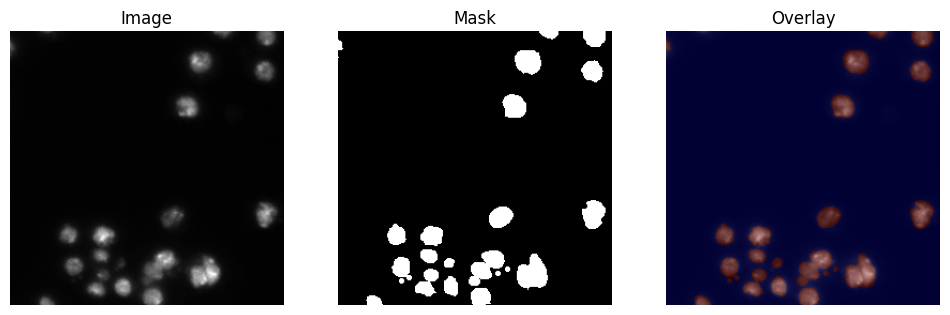

In [6]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# path to converted dataset
root = r"C:\Users\Syed\segmentation\nuclei_data"

# pick one sample
sample = os.listdir(root)[0]
sample_path = os.path.join(root, sample)

print("Sample:", sample)

# -------------------------
# LOAD IMAGE & MASK
# -------------------------
img_path = os.path.join(sample_path, "image.tif")
mask_path = os.path.join(sample_path, "mask.tif")

image = np.array(Image.open(img_path))
mask = np.array(Image.open(mask_path))

# -------------------------
# BASIC CHECKS
# -------------------------
print("\n--- BASIC INFO ---")
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

print("Image dtype:", image.dtype)
print("Mask dtype:", mask.dtype)

print("Image min/max:", image.min(), image.max())
print("Mask unique:", np.unique(mask))

# -------------------------
# ASSERTIONS (IMPORTANT)
# -------------------------
assert image.shape == (256, 256), " Image size incorrect"
assert mask.shape == (256, 256), " Mask size incorrect"
assert set(np.unique(mask)).issubset({0, 255}), " Mask not binary"

print("\n All structural checks passed")

# -------------------------
# VISUALIZATION
# -------------------------
plt.figure(figsize=(12, 4))

# image
plt.subplot(1, 3, 1)
plt.title("Image")
plt.imshow(image, cmap="gray")
plt.axis("off")

# mask
plt.subplot(1, 3, 2)
plt.title("Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

# overlay
plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(image, cmap="gray")
plt.imshow(mask, cmap="jet", alpha=0.4)
plt.axis("off")

plt.show()

In [7]:
import os
import shutil
import random

# -------------------------
# CONFIG
# -------------------------
src = r"C:\Users\Syed\segmentation\nuclei_data"

train_dst = r"C:\Users\Syed\segmentation\nuclei_train_data"
val_dst = r"C:\Users\Syed\segmentation\nuclei_val_data"

split_ratio = 0.8
seed = 42

# -------------------------
# SET SEED (REPRODUCIBILITY)
# -------------------------
random.seed(seed)

# -------------------------
# LOAD SAMPLES
# -------------------------
samples = os.listdir(src)
samples = [s for s in samples if os.path.isdir(os.path.join(src, s))]

print("Total samples:", len(samples))

# shuffle deterministically
random.shuffle(samples)

# split
split_idx = int(len(samples) * split_ratio)

train_samples = samples[:split_idx]
val_samples = samples[split_idx:]

print("Train samples:", len(train_samples))
print("Val samples:", len(val_samples))

# -------------------------
# COPY FUNCTION
# -------------------------
def copy_samples(sample_list, destination):
    os.makedirs(destination, exist_ok=True)

    for s in sample_list:
        src_path = os.path.join(src, s)
        dst_path = os.path.join(destination, s)

        shutil.copytree(src_path, dst_path, dirs_exist_ok=True)

# -------------------------
# EXECUTE SPLIT
# -------------------------
copy_samples(train_samples, train_dst)
copy_samples(val_samples, val_dst)

print(" Train/Val split COMPLETE")

Total samples: 669
Train samples: 535
Val samples: 134
 Train/Val split COMPLETE


In [8]:
print("\nOverlap check:",
      set(train_samples).intersection(set(val_samples)))


Overlap check: set()
